# Cognitive Sensing & Network Telemetry

In this notebook, you'll learn how to:
1. Simulate Kota's real-time network telemetry event stream
2. Detect anomalous bandwidth spikes that indicate potential data exfiltration
3. Visualize network throughput timeseries and threat detection thresholds
4. Understand how the Cognitive Radar maps to the MIMO/CR security framework in the research paper

## Setup: The Sensing Subsystem

Kota's `src/sensing.rs` module runs as an asynchronous Tokio task alongside the LLM and TUI engines. Every second, it polls all network interfaces using the `sysinfo` crate (zero-privilege, no sudo required) and broadcasts telemetry into the central event bus.

The Rust event types are:
```rust
AgentEvent::TelemetryUpdate { rx_kbps: f64, tx_kbps: f64 }
AgentEvent::NetworkThreatDetected { severity: String, description: String }
```

Below, we simulate this event stream in Python to visualize how the radar works.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Simulate 120 seconds of network telemetry ---
TIMESTEPS = 120
THRESHOLD_KBPS = 500_000.0  # 500 Mbps outbound = threat

# Normal baseline: ~50 Kbps Tx, ~200 Kbps Rx with noise
tx_baseline = np.random.normal(loc=50, scale=15, size=TIMESTEPS)
rx_baseline = np.random.normal(loc=200, scale=40, size=TIMESTEPS)

# Inject an exfiltration attack at t=45..55 (massive outbound spike)
tx_baseline[45:55] = np.random.normal(loc=600_000, scale=50_000, size=10)

# Inject a smaller suspicious burst at t=85..90
tx_baseline[85:90] = np.random.normal(loc=300_000, scale=20_000, size=5)

tx_kbps = np.clip(tx_baseline, 0, None)
rx_kbps = np.clip(rx_baseline, 0, None)

# --- Generate the event stream (mirrors what sensing.rs broadcasts) ---
events = []
for t in range(TIMESTEPS):
    if tx_kbps[t] > THRESHOLD_KBPS:
        events.append(
            {
                "type": "NetworkThreatDetected",
                "time": t,
                "severity": "CRITICAL",
                "description": f"Massive outbound spike: {tx_kbps[t]:.0f} Kbps",
            }
        )
    else:
        events.append(
            {
                "type": "TelemetryUpdate",
                "time": t,
                "tx_kbps": round(float(tx_kbps[t]), 2),
                "rx_kbps": round(float(rx_kbps[t]), 2),
            }
        )

# Show a few normal events and the first threat
print("── Sample Telemetry Events ──")
for e in events[:3]:
    print(json.dumps(e, indent=2))
print("...")
threats = [e for e in events if e["type"] == "NetworkThreatDetected"]
print(f"\n🚨 Total threats detected: {len(threats)}")
print(json.dumps(threats[0], indent=2))

── Sample Telemetry Events ──
{
  "type": "TelemetryUpdate",
  "time": 0,
  "tx_kbps": 57.45,
  "rx_kbps": 231.64
}
{
  "type": "TelemetryUpdate",
  "time": 1,
  "tx_kbps": 47.93,
  "rx_kbps": 163.62
}
{
  "type": "TelemetryUpdate",
  "time": 2,
  "tx_kbps": 59.72,
  "rx_kbps": 256.11
}
...

🚨 Total threats detected: 10
{
  "type": "NetworkThreatDetected",
  "time": 45,
  "severity": "CRITICAL",
  "description": "Massive outbound spike: 560374 Kbps"
}


## Visualizing the Cognitive Radar

The plot below shows how the telemetry loop tracks outbound (Tx) bandwidth over time. The red dashed line represents the configurable threat threshold (`500 Mbps`). When Tx spikes above this line, the radar triggers a `NetworkThreatDetected` event and Kota immediately enters its restricted sandbox protocol.

Notice the two spikes:
- **t=45–55**: A full exfiltration attack. All 10 seconds exceed the threshold → 10 `CRITICAL` alerts fired.
- **t=85–90**: A suspicious burst that stays *below* the threshold → no alert. This is where future refinement (e.g., rolling-window entropy analysis from the Markov Channel model) would help detect slower, stealthier attacks.

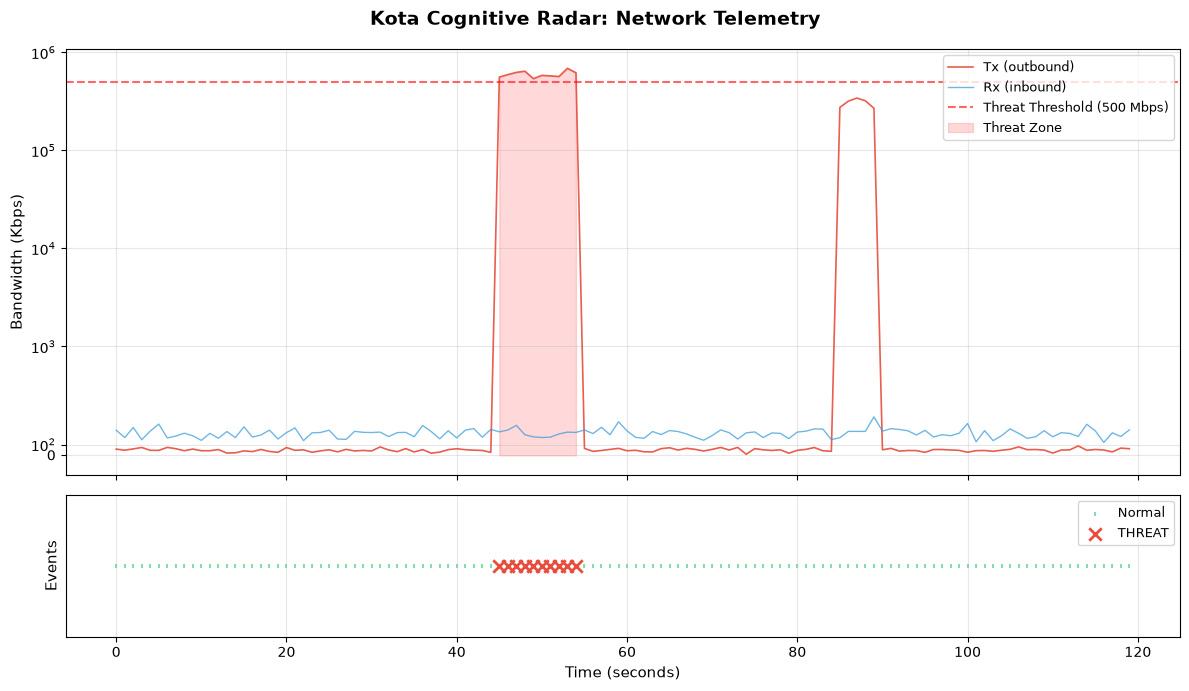

In [2]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
fig.suptitle("Kota Cognitive Radar: Network Telemetry", fontsize=14, fontweight="bold")

t = np.arange(TIMESTEPS)

# --- Top: Bandwidth over time ---
ax1.plot(t, tx_kbps, color="#E74C3C", linewidth=1.2, alpha=0.9, label="Tx (outbound)")
ax1.plot(t, rx_kbps, color="#3498DB", linewidth=1.0, alpha=0.7, label="Rx (inbound)")
ax1.axhline(
    y=THRESHOLD_KBPS,
    color="red",
    linestyle="--",
    linewidth=1.5,
    alpha=0.6,
    label=f"Threat Threshold ({THRESHOLD_KBPS/1000:.0f} Mbps)",
)

# Shade threat zones
threat_mask = tx_kbps > THRESHOLD_KBPS
ax1.fill_between(
    t, 0, tx_kbps, where=threat_mask, color="red", alpha=0.15, label="Threat Zone"
)

ax1.set_ylabel("Bandwidth (Kbps)", fontsize=11)
ax1.set_yscale("symlog", linthresh=1000)
ax1.legend(loc="upper right", fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Bottom: Alert timeline ---
alert_times = [e["time"] for e in events if e["type"] == "NetworkThreatDetected"]
normal_times = [e["time"] for e in events if e["type"] == "TelemetryUpdate"]

ax2.scatter(
    normal_times,
    [0] * len(normal_times),
    color="#2ECC71",
    s=12,
    marker="|",
    label="Normal",
    alpha=0.6,
)
ax2.scatter(
    alert_times,
    [0] * len(alert_times),
    color="#E74C3C",
    s=80,
    marker="x",
    linewidths=2,
    label="THREAT",
    zorder=5,
)

ax2.set_xlabel("Time (seconds)", fontsize=11)
ax2.set_ylabel("Events", fontsize=11)
ax2.set_yticks([])
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Simulating the TUI Status Bar

In Kota's TUI, the telemetry is rendered as a compact status bar at the bottom of the screen. Here's what the user would see during normal operation and during a threat event:

In [3]:
def render_status_bar(event):
    """Simulate Kota's TUI status bar for a given telemetry event."""
    if event["type"] == "TelemetryUpdate":
        bar = f" mode: CODER | step 4 | last: 1200ms | tx: {event['tx_kbps']:.1f}kbps | rx: {event['rx_kbps']:.1f}kbps"
        print(f"\033[48;5;236m\033[38;5;245m{bar:<80}\033[0m")
    elif event["type"] == "NetworkThreatDetected":
        bar = f" 🚨 THREAT [{event['severity']}]: {event['description']}"
        print(f"\033[48;5;52m\033[38;5;196m{bar:<80}\033[0m")


print("╭─ Kota Mock TUI ───────────────────────────────────────────╮")
print("│                                                            │")
print("│  Normal operation (t=10):                                  │")
render_status_bar(events[10])
print()
print("│  During exfiltration attack (t=47):                        │")
render_status_bar(events[47])
print()
print("│  Back to normal (t=70):                                    │")
render_status_bar(events[70])
print("╰────────────────────────────────────────────────────────────╯")

╭─ Kota Mock TUI ───────────────────────────────────────────╮
│                                                            │
│  Normal operation (t=10):                                  │
 mode: CODER | step 4 | last: 1200ms | tx: 43.0kbps | rx: 138.0kbps             

│  During exfiltration attack (t=47):                        │
 🚨 THREAT [CRITICAL]: Massive outbound spike: 625249 Kbps                       

│  Back to normal (t=70):                                    │
 mode: CODER | step 4 | last: 1200ms | tx: 55.4kbps | rx: 182.1kbps             
╰────────────────────────────────────────────────────────────╯


## Connection to the Research Paper

The sensing subsystem directly implements two of the three pillars from the *Cognitive RF Security* section of the Kota technical report:

| Research Concept | Equation | Implementation |
|---|---|---|
| **MIMO Spatial Diversity** | $\mathbf{y}_i = \mathbf{H}_i \mathbf{x} + \mathbf{n}_i$ | Future: ensemble sub-agents with varying temperatures, synthesized via beamforming |
| **Cognitive Radar** | $\Lambda(\mathbf{c}) = \sum_j \|c_j\|^2 > \gamma$ | **Implemented**: `sensing.rs` energy thresholding on Tx bandwidth |
| **Markov Channel Capacity** | $C = \lim_{n\to\infty} \frac{1}{n} \max I(X^n; Y^n)$ | Future: rolling-window perplexity/entropy monitoring on context trace |

## Summary

In this notebook, you:

- Simulated 120 seconds of Kota network telemetry, including a realistic exfiltration attack
- Generated the same `AgentEvent::TelemetryUpdate` and `AgentEvent::NetworkThreatDetected` events that `src/sensing.rs` broadcasts on the Tokio event bus
- Visualized the Cognitive Radar with a dual-panel plot showing bandwidth timeseries and an alert timeline
- Rendered a mock TUI status bar showing how real-time telemetry appears to the user
- Connected the implementation back to the MIMO, Cognitive Radio, and Markov Channel theory in the research paper